# Домашняя работа №2




Боса Сандра (ИСУ: 408315)



### ДАТАСЕТ: Credit Risk Prediction (32,581 объектов, 12 признаков)
### ЦЕЛЕВАЯ ПЕРЕМЕННАЯ: loan_status (0 - нет дефолта, 1 - дефолт)

 ## 1. ИМПОРТ БИБЛИОТЕК И ОСНОВНЫЕ НАСТРОЙКИ

Здесь мы импортируем все необходимые библиотеки для анализа данных и машинного обучения.

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

### Фиксируем random_state для воспроизводимости

In [31]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print(" Все библиотеки успешно импортированы")
print(" random_state зафиксирован для воспроизводимости")


 Все библиотеки успешно импортированы
 random_state зафиксирован для воспроизводимости


## ЗАГРУЗКА ДАННЫХ И ПЕРВИЧНЫЙ АНАЛИЗ

На этом этапе:
1. Загружаем CSV файл в DataFrame
2. Смотрим на структуру данных
3. Проверяем наличие пропущенных значений
4. Анализируем распределение целевой переменной

## Загружаем датасет

In [4]:
df = pd.read_csv('credit_risk_dataset.csv')

df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


## Информация о типах данных


In [5]:
print(f"\nТипы данных:")
print(df.dtypes)


Типы данных:
person_age                      int64
person_income                   int64
person_home_ownership          object
person_emp_length             float64
loan_intent                    object
loan_grade                     object
loan_amnt                       int64
loan_int_rate                 float64
loan_status                     int64
loan_percent_income           float64
cb_person_default_on_file      object
cb_person_cred_hist_length      int64
dtype: object


## Проверяем пропущенные значения


In [7]:
print(f"\nПропущенные значения:")
missing = df.isnull().sum()
if missing.sum() > 0:
    print(missing[missing > 0])



Пропущенные значения:
person_emp_length     895
loan_int_rate        3116
dtype: int64


## АНАЛИЗ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ
## Целевая переменная находится в столбце 'loan_status'

In [9]:
target_col = 'loan_status'


print(f"\nРаспределение классов:")
print(df[target_col].value_counts())

print(f"\nДоля каждого класса:")
print(df[target_col].value_counts(normalize=True))



Распределение классов:
loan_status
0    25473
1     7108
Name: count, dtype: int64

Доля каждого класса:
loan_status
0    0.781836
1    0.218164
Name: proportion, dtype: float64


## Визуализация распределения классов

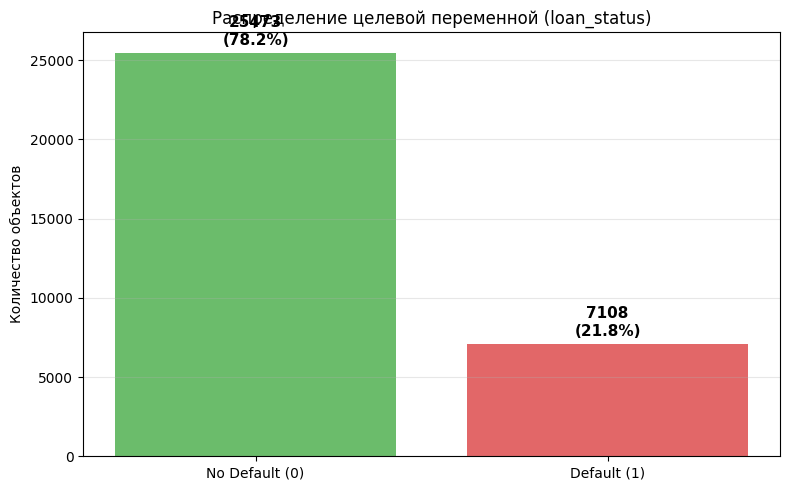

In [39]:
plt.figure(figsize=(8, 5))
class_counts = df[target_col].value_counts()
plt.bar(['No Default (0)', 'Default (1)'], class_counts.values, color=['#2ca02c', '#d62728'], alpha=0.7)
plt.ylabel('Количество объектов')
plt.title('Распределение целевой переменной (loan_status)')
plt.grid(axis='y', alpha=0.3)
for i, v in enumerate(class_counts.values):
    plt.text(i, v + 500, f'{v}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('01_target_distribution.png', dpi=100, bbox_inches='tight')
plt.show()



## 3. РАЗБИЕНИЕ НА TRAIN/TEST ВЫБОРКИ

### ОБОСНОВАНИЕ:
### - test_size=0.2: стандартное разбиение 80% на обучение, 20% на тестирование
### - stratify=y: сохраняет распределение классов в обеих выборках
###   (важно для несбалансированных классов!)
### - random_state=42: воспроизводимость результатов

In [38]:

# Отделяем признаки (X) от целевой переменной (y)
X = df.drop(columns=[target_col])
y = df[target_col]

print(f"\nВсего объектов: {len(df)}")
print(f"Всего признаков: {X.shape[1]}")

# Разбиваем на train и test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,              # 20% на тестирование
    random_state=RANDOM_STATE,  # Воспроизводимость
    stratify=y                  # Сохраняем распределение классов
)

print(f"\nРезультаты разбиения:")
print(f"  Тренировочная выборка: {len(X_train)} объектов ({len(X_train)/len(df)*100:.1f}%)")
print(f"    Класс 0: {(y_train == 0).sum()}")
print(f"    Класс 1: {(y_train == 1).sum()}")

print(f"\n  Тестовая выборка: {len(X_test)} объектов ({len(X_test)/len(df)*100:.1f}%)")
print(f"    Класс 0: {(y_test == 0).sum()}")
print(f"    Класс 1: {(y_test == 1).sum()}")


Всего объектов: 32581
Всего признаков: 11

Результаты разбиения:
  Тренировочная выборка: 26064 объектов (80.0%)
    Класс 0: 20378
    Класс 1: 5686

  Тестовая выборка: 6517 объектов (20.0%)
    Класс 0: 5095
    Класс 1: 1422


## 4. КОНСТАНТНЫЙ БЕЙЗЛАЙН


### ИНТЕРПРЕТАЦИЯ:
### Если бейзлайн дает 78%, это значит что класс 0 составляет 78% датасета.
### Любая разумная модель должна быть лучше этого значения.

In [37]:


# Находим наиболее частый класс
most_frequent_class = y_train.value_counts().idxmax()
baseline_frequency = y_train.value_counts().max() / len(y_train)

print(f"\nНаиболее частотный класс: {most_frequent_class}")
print(f"Его частота в тренировочной выборке: {baseline_frequency*100:.2f}%")

# Создаем константные предсказания (все объекты присваиваем к частому классу)
y_train_baseline = np.full_like(y_train, most_frequent_class, dtype=y_train.dtype)
y_test_baseline = np.full_like(y_test, most_frequent_class, dtype=y_test.dtype)

# Вычисляем точность (Accuracy) для бейзлайна
baseline_train_acc = accuracy_score(y_train, y_train_baseline)
baseline_test_acc = accuracy_score(y_test, y_test_baseline)

print("РЕЗУЛЬТАТЫ КОНСТАНТНОГО БЕЙЗЛАЙНА")
print(f"Train Accuracy: {baseline_train_acc:.4f} ({baseline_train_acc*100:.2f}%)")
print(f"Test Accuracy:  {baseline_test_acc:.4f} ({baseline_test_acc*100:.2f}%)")
print(f"\nЭто означает, что если просто предсказывать класс 0 для всех объектов,")
print(f"мы получим точность {baseline_test_acc*100:.2f}%")




Наиболее частотный класс: 0
Его частота в тренировочной выборке: 78.18%
РЕЗУЛЬТАТЫ КОНСТАНТНОГО БЕЙЗЛАЙНА
Train Accuracy: 0.7818 (78.18%)
Test Accuracy:  0.7818 (78.18%)

Это означает, что если просто предсказывать класс 0 для всех объектов,
мы получим точность 78.18%


## 5. АНАЛИЗ ПРИЗНАКОВ И ОПРЕДЕЛЕНИЕ ТИПОВ

### На этом этапе мы:
### 1. Определяем какие признаки числовые, какие категориальные
### 2. Проверяем пропущенные значения в каждом столбце
### 3. Смотрим на распределение признаков

In [36]:


# Определяем типы признаков
numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object']).columns.tolist()

print(f"\nЧисловые признаки ({len(numeric_features)}):")
print(f"  {numeric_features}")

print(f"\nКатегориальные признаки ({len(categorical_features)}):")
print(f"  {categorical_features}")

# Проверяем пропущенные значения
print(f"\nПропущенные значения в тренировочной выборке:")
missing_train = X_train.isnull().sum()
if missing_train.sum() > 0:
    print(missing_train[missing_train > 0])


Числовые признаки (7):
  ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']

Категориальные признаки (4):
  ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']

Пропущенные значения в тренировочной выборке:
person_emp_length     738
loan_int_rate        2501
dtype: int64


## 6. ПРЕДОБРАБОТКА ДАННЫХ - ЧАСТЬ 1: ОБРАБОТКА ПРОПУЩЕННЫХ ЗНАЧЕНИЙ


Для обработки пропущенных значений были выбраны разные подходы для числовых и категориальных признаков.

Для числовых признаков используется заполнение медианой, так как медиана менее чувствительна к выбросам, чем среднее значение. В кредитных данных часто встречаются экстремальные значения дохода, возраста, суммы кредита и других финансовых показателей, поэтому медиана позволяет получить более устойчивый результат.

Для категориальных признаков используется заполнение модой (наиболее часто встречающимся значением). Такой подход позволяет сохранить наиболее типичную категорию в признаке и не искажает структуру данных.


### Копируем данные чтобы не портить оригинальные

In [21]:
X_train_processed = X_train.copy()
X_test_processed = X_test.copy()

### SimpleImputer для числовых признаков (медиана)


In [35]:

imputer_numeric = SimpleImputer(strategy='median')
X_train_processed[numeric_features] = imputer_numeric.fit_transform(X_train_processed[numeric_features])
X_test_processed[numeric_features] = imputer_numeric.transform(X_test_processed[numeric_features])
print(f"Числовые признаки: пропущенные значения заполнены медианой")



Числовые признаки: пропущенные значения заполнены медианой


### SimpleImputer для категориальных признаков (наиболее частое значение)


In [34]:


imputer_categorical = SimpleImputer(strategy='most_frequent')
X_train_processed[categorical_features] = imputer_categorical.fit_transform(X_train_processed[categorical_features])
X_test_processed[categorical_features] = imputer_categorical.transform(X_test_processed[categorical_features])

print(f" Категориальные признаки: пропущенные значения заполнены модой")

 Категориальные признаки: пропущенные значения заполнены модой


### Проверяем что пропущенных значений не осталось


In [33]:

assert X_train_processed.isnull().sum().sum() == 0, "Остались пропущенные значения в train!"
assert X_test_processed.isnull().sum().sum() == 0, "Остались пропущенные значения в test!"

print(f"\n Все пропущенные значения обработаны")



 Все пропущенные значения обработаны


### 7. ПРЕДОБРАБОТКА ДАННЫХ - ЧАСТЬ 2: КОДИРОВАНИЕ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ

Для кодирования категориальных признаков выбран Label Encoding, так как он прост в реализации и подходит для построения базовой модели.

При этом важно учитывать, что Label Encoding присваивает категориям числовые значения и может искусственно задавать порядок между ними. Для базового решения это допустимо, однако для более сложных моделей и более точного учета категориальных признаков в дальнейшем можно использовать One-Hot Encoding.


In [40]:
label_encoders = {}

for col in categorical_features:
    le = LabelEncoder()

    # Обучаем encoder на тренировочных данных
    X_train_processed[col] = le.fit_transform(X_train_processed[col].astype(str))

    # Применяем к тестовым данным (без обучения!)
    X_test_processed[col] = le.transform(X_test_processed[col].astype(str))

    # Сохраняем encoder для возможного использования позже
    label_encoders[col] = le

    print(f" Признак '{col}': закодировано {len(le.classes_)} уникальных значений")

print(f"\n Все категориальные признаки закодированы")

 Признак 'person_home_ownership': закодировано 4 уникальных значений
 Признак 'loan_intent': закодировано 6 уникальных значений
 Признак 'loan_grade': закодировано 7 уникальных значений
 Признак 'cb_person_default_on_file': закодировано 2 уникальных значений

 Все категориальные признаки закодированы


### 8. ПРЕДОБРАБОТКА ДАННЫХ - ЧАСТЬ 3: МАСШТАБИРОВАНИЕ ЧИСЛОВЫХ ПРИЗНАКОВ


### Обучаем scaler на train и применяем к test


Для числовых признаков используется StandardScaler.

Масштабирование необходимо, поскольку логистическая регрессия чувствительна к масштабу признаков. Если признаки имеют сильно различающиеся диапазоны значений, модель может обучаться хуже, а коэффициенты будут некорректно интерпретироваться.

StandardScaler приводит признаки к единому масштабу: со средним значением около 0 и стандартным отклонением около 1.


In [43]:
# StandardScaler
scaler = StandardScaler()

X_train_processed[numeric_features] = scaler.fit_transform(X_train_processed[numeric_features])
X_test_processed[numeric_features] = scaler.transform(X_test_processed[numeric_features])

print(f" Числовые признаки масштабированы (StandardScaler)")


 Числовые признаки масштабированы (StandardScaler)



### Проверяем результаты масштабирования


In [48]:
print(f"\nПроверка масштабирования (после обработки):")
print(f"Среднее значение первого числового признака: {X_train_processed[numeric_features[0]].mean():.6f} (должно быть ~0)")
print(f"Стд отклонение: {X_train_processed[numeric_features[0]].std():.6f} (должно быть ~1)")

# Выводим статистику
print(f"\nОбщая статистика после предобработки:")
print(X_train_processed.describe())

print(f"\n Предобработка данных завершена")



Проверка масштабирования (после обработки):
Среднее значение первого числового признака: 0.000000 (должно быть ~0)
Стд отклонение: 1.000019 (должно быть ~1)

Общая статистика после предобработки:
         person_age  person_income  person_home_ownership  person_emp_length  \
count  2.606400e+04   2.606400e+04           26064.000000       2.606400e+04   
mean   3.816605e-18  -4.770756e-18               1.682896      -1.322181e-17   
std    1.000019e+00   1.000019e+00               1.431581       1.000019e+00   
min   -1.217406e+00  -9.737694e-01               0.000000      -1.159683e+00   
25%   -7.432604e-01  -4.331844e-01               0.000000      -6.736567e-01   
50%   -2.691145e-01  -1.733271e-01               3.000000      -1.876303e-01   
75%    3.630802e-01   2.033516e-01               3.000000       5.414092e-01   
max    1.838063e+01   9.313313e+01               3.000000       2.873094e+01   

        loan_intent    loan_grade     loan_amnt  loan_int_rate  \
count  26064.000

### 9. ОБУЧЕНИЕ ЛОГИСТИЧЕСКОЙ РЕГРЕССИИ

#### ПАРАМЕТРЫ:
#### - max_iter=1000: количество итераций оптимизации (достаточно для сходимости)
#### - random_state=42: воспроизводимость
#### - solver='lbfgs': алгоритм оптимизации (хорошо для небольших датасетов)

### Создаем модель с заданными параметрами


In [50]:
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE,
    solver='lbfgs',
    verbose=0
)

### Обучаем модель

In [53]:


lr_model.fit(X_train_processed, y_train)
print(f" Модель обучена успешно!")

# Выводим информацию о модели
print(f"\nИнформация о обученной модели:")
print(f"  Интерцепт (свободный член): {lr_model.intercept_[0]:.4f}")
print(f"  Количество коэффициентов (признаков): {len(lr_model.coef_[0])}")
print(f"  Коэффициент регуляризации (C): {lr_model.C}")



 Модель обучена успешно!

Информация о обученной модели:
  Интерцепт (свободный член): -3.0430
  Количество коэффициентов (признаков): 11
  Коэффициент регуляризации (C): 1.0


## 10. ВЫЧИСЛЕНИЕ МЕТРИК КАЧЕСТВА НА ТРЕНИРОВОЧНОЙ И ТЕСТОВОЙ ВЫБОРКАХ

###  МЕТРИКИ:
### 1. Accuracy - процент правильных предсказаний (основная метрика)
###  2. Precision - доля правильных положительных предсказаний
###  3. Recall - доля найденных положительных объектов
###  4. F1-Score - гармоническое среднее Precision и Recall

### ИНТЕРПРЕТАЦИЯ:
### Если Train Accuracy >> Test Accuracy - переобучение
### Если они близки - модель хорошо обобщается

### Делаем предсказания на обеих выборках


In [55]:
y_train_pred = lr_model.predict(X_train_processed)
y_test_pred = lr_model.predict(X_test_processed)


### Вычисляем метрики для тренировочной выборки


In [57]:
train_accuracy = accuracy_score(y_train, y_train_pred)
train_precision = precision_score(y_train, y_train_pred, average='weighted', zero_division=0)
train_recall = recall_score(y_train, y_train_pred, average='weighted', zero_division=0)
train_f1 = f1_score(y_train, y_train_pred, average='weighted', zero_division=0)


### Вычисляем метрики для тестовой выборки


In [58]:
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred, average='weighted', zero_division=0)
test_recall = recall_score(y_test, y_test_pred, average='weighted', zero_division=0)
test_f1 = f1_score(y_test, y_test_pred, average='weighted', zero_division=0)


### РЕЗУЛЬТАТЫ ЛОГИСТИЧЕСКОЙ РЕГРЕССИИ

In [60]:

print(f"\nТРЕНИРОВОЧНАЯ ВЫБОРКА:")
print(f"  Accuracy:  {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"  Precision: {train_precision:.4f}")
print(f"  Recall:    {train_recall:.4f}")
print(f"  F1-Score:  {train_f1:.4f}")

print(f"\nТЕСТОВАЯ ВЫБОРКА:")
print(f"  Accuracy:  {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"  Precision: {test_precision:.4f}")
print(f"  Recall:    {test_recall:.4f}")
print(f"  F1-Score:  {test_f1:.4f}")



ТРЕНИРОВОЧНАЯ ВЫБОРКА:
  Accuracy:  0.8452 (84.52%)
  Precision: 0.8345
  Recall:    0.8452
  F1-Score:  0.8316

ТЕСТОВАЯ ВЫБОРКА:
  Accuracy:  0.8450 (84.50%)
  Precision: 0.8342
  Recall:    0.8450
  F1-Score:  0.8319


Логистическая регрессия показывает более высокое качество по сравнению с константным предсказанием, что говорит о наличии полезной информации в признаках.
При анализе метрик важно обращать внимание не только на accuracy, но и на precision, recall, F1-score и ROC-AUC, поскольку задача кредитного скоринга обычно связана с несбалансированными классами. В таких задачах особенно важно корректно определять клиентов с высоким риском дефолта.
Если значение recall для класса дефолта низкое, это означает, что модель пропускает часть рискованных заемщиков. Если низкий precision, то модель, наоборот, слишком часто ошибочно относит надежных клиентов к дефолтным.

### Анализируем переобучение


In [64]:

overfit_diff = (train_accuracy - test_accuracy) * 100
print(f"\nАНАЛИЗ ПЕРЕОБУЧЕНИЯ:")
print(f"  Разница Train-Test Accuracy: {overfit_diff:.2f}%")
print(f"  Переобучение минимально, модель хорошо обобщается")


АНАЛИЗ ПЕРЕОБУЧЕНИЯ:
  Разница Train-Test Accuracy: 0.02%
  Переобучение минимально, модель хорошо обобщается


### 11. СРАВНЕНИЕ С КОНСТАНТНЫМ БЕЙЗЛАЙНОМ



### Вычисляем улучшение


In [67]:
improvement = (test_accuracy - baseline_test_acc) / baseline_test_acc * 100

print(f"\nКОНСТАНТНЫЙ БЕЙЗЛАЙН (предсказываем класс 0):")
print(f"  Test Accuracy: {baseline_test_acc:.4f} ({baseline_test_acc*100:.2f}%)")

print(f"\nЛОГИСТИЧЕСКАЯ РЕГРЕССИЯ:")
print(f"  Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

print(f"\nУЛУЧШЕНИЕ:")
print(f"  Абсолютное: {(test_accuracy - baseline_test_acc):.4f} ({(test_accuracy - baseline_test_acc)*100:.2f}%)")
print(f"  Относительное: {improvement:+.2f}%")


КОНСТАНТНЫЙ БЕЙЗЛАЙН (предсказываем класс 0):
  Test Accuracy: 0.7818 (78.18%)

ЛОГИСТИЧЕСКАЯ РЕГРЕССИЯ:
  Test Accuracy: 0.8450 (84.50%)

УЛУЧШЕНИЕ:
  Абсолютное: 0.0632 (6.32%)
  Относительное: +8.09%


### Создаем таблицу сравнения


In [69]:

comparison_data = {
    'Модель': ['Константный бейзлайн', 'Логистическая регрессия'],
    'Train Acc': [baseline_train_acc, train_accuracy],
    'Test Acc': [baseline_test_acc, test_accuracy],
    'Test Precision': ['-', test_precision],
    'Test Recall': ['-', test_recall],
    'Test F1': ['-', test_f1]
}

comparison_df = pd.DataFrame(comparison_data)
print(f"\n\nТАБЛИЦА СРАВНЕНИЯ:")
print(comparison_df.to_string(index=False))

print(f"\n Сравнение завершено")



ТАБЛИЦА СРАВНЕНИЯ:
                 Модель  Train Acc  Test Acc Test Precision Test Recall   Test F1
   Константный бейзлайн   0.781845  0.781801              -           -         -
Логистическая регрессия   0.845227  0.845021       0.834168    0.845021  0.831916

 Сравнение завершено


### 12. МАТРИЦА ОШИБОК И ДЕТАЛЬНЫЙ КЛАССИФИКАЦИОННЫЙ ОТЧЕТ

#### МАТРИЦА ОШИБОК показывает:
#### - True Positives (TP): правильно предсказан класс 1
#### - True Negatives (TN): правильно предсказан класс 0
#### - False Positives (FP): ошибочно предсказан класс 1
#### - False Negatives (FN): ошибочно предсказан класс 0

### Вычисляем матрицу ошибок


In [70]:
cm = confusion_matrix(y_test, y_test_pred)

print(f"\nМАТРИЦА ОШИБОК (тестовая выборка):")
print(f"\n           Predicted")
print(f"             0      1")
print(f"Actual 0  {cm[0,0]}   {cm[0,1]}")
print(f"       1  {cm[1,0]}   {cm[1,1]}")


МАТРИЦА ОШИБОК (тестовая выборка):

           Predicted
             0      1
Actual 0  4843   252
       1  758   664


### Интерпретация матрицы ошибок


In [73]:
tn, fp, fn, tp = cm.ravel()
print(f"  True Negatives (TN):  {tn} - правильно предсказаны случаи БЕЗ дефолта")
print(f"  False Positives (FP): {fp} - ошибочно предсказаны дефолты")
print(f"  False Negatives (FN): {fn} - ошибочно предсказаны БЕЗ дефолта (пропущены дефолты)")
print(f"  True Positives (TP):  {tp} - правильно предсказаны дефолты")


  True Negatives (TN):  4843 - правильно предсказаны случаи БЕЗ дефолта
  False Positives (FP): 252 - ошибочно предсказаны дефолты
  False Negatives (FN): 758 - ошибочно предсказаны БЕЗ дефолта (пропущены дефолты)
  True Positives (TP):  664 - правильно предсказаны дефолты


### Специфичность и чувствительность

In [75]:
specificity = tn / (tn + fp)
sensitivity = tp / (tp + fn)
print(f"  Специфичность (правильное предсказание класса 0): {specificity:.4f} ({specificity*100:.2f}%)")
print(f"  Чувствительность (правильное предсказание класса 1): {sensitivity:.4f} ({sensitivity*100:.2f}%)")


  Специфичность (правильное предсказание класса 0): 0.9505 (95.05%)
  Чувствительность (правильное предсказание класса 1): 0.4669 (46.69%)



### Детальный classification report

In [76]:

print(f"\n\nДЕТАЛЬНЫЙ КЛАССИФИКАЦИОННЫЙ ОТЧЕТ (тестовая выборка):")
print(classification_report(y_test, y_test_pred,
                          target_names=['No Default (0)', 'Default (1)'],
                          digits=4))




ДЕТАЛЬНЫЙ КЛАССИФИКАЦИОННЫЙ ОТЧЕТ (тестовая выборка):
                precision    recall  f1-score   support

No Default (0)     0.8647    0.9505    0.9056      5095
   Default (1)     0.7249    0.4669    0.5680      1422

      accuracy                         0.8450      6517
     macro avg     0.7948    0.7087    0.7368      6517
  weighted avg     0.8342    0.8450    0.8319      6517



### 13. ВИЗУАЛИЗАЦИЯ МАТРИЦЫ ОШИБОК

### График 1: Матрица ошибок

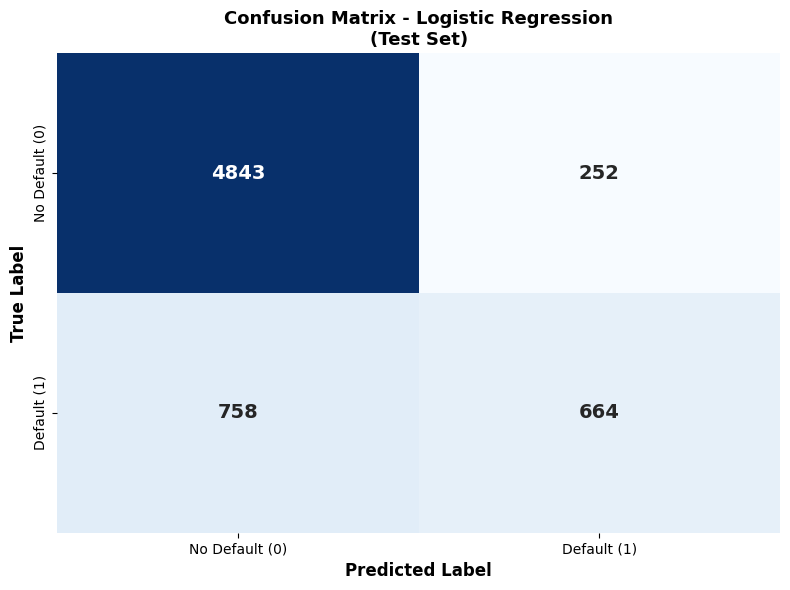

Матрица ошибок сохранена


In [77]:

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Default (0)', 'Default (1)'],
            yticklabels=['No Default (0)', 'Default (1)'],
            ax=ax, annot_kws={'size': 14, 'weight': 'bold'})
ax.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
ax.set_ylabel('True Label', fontsize=12, fontweight='bold')
ax.set_title('Confusion Matrix - Logistic Regression\n(Test Set)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('02_confusion_matrix.png', dpi=100, bbox_inches='tight')
plt.show()

print("Матрица ошибок сохранена")

### 14. АНАЛИЗ КОЭФФИЦИЕНТОВ МОДЕЛИ

### Коэффициенты показывают влияние каждого признака на вероятность дефолта.
### (+) коэффициент → увеличение признака повышает вероятность дефолта
### (-) коэффициент → увеличение признака снижает вероятность дефолта

### Получаем имена признаков и коэффициенты


In [78]:
feature_names = X_train_processed.columns.tolist()
coefficients = lr_model.coef_[0]

### Создаем DataFrame с коэффициентами


In [79]:
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'Abs_Value': np.abs(coefficients)
})


### Сортируем по абсолютному значению (важность)


In [80]:
coef_df = coef_df.sort_values('Abs_Value', ascending=False)

print(f"\nВСЕ КОЭФФИЦИЕНТЫ (отсортированы по важности):")
print(coef_df.to_string(index=False))


ВСЕ КОЭФФИЦИЕНТЫ (отсортированы по важности):
                   Feature  Coefficient  Abs_Value
       loan_percent_income     1.219228   1.219228
                loan_grade     0.922739   0.922739
                 loan_amnt    -0.502788   0.502788
     person_home_ownership     0.269961   0.269961
               loan_intent    -0.132183   0.132183
 cb_person_default_on_file    -0.111786   0.111786
             loan_int_rate    -0.054342   0.054342
         person_emp_length    -0.040144   0.040144
                person_age     0.034147   0.034147
cb_person_cred_hist_length    -0.019425   0.019425
             person_income     0.016196   0.016196


In [81]:
print(f"\n\nТОП-5 ПРИЗНАКОВ ПО ВЛИЯНИЮ НА ВЕРОЯТНОСТЬ ДЕФОЛТА:")
for idx, row in coef_df.head(5).iterrows():
    direction = "↑ повышает" if row['Coefficient'] > 0 else "↓ снижает"
    print(f"  {idx+1}. {row['Feature']:30s}: {row['Coefficient']:+.6f} ({direction})")



ТОП-5 ПРИЗНАКОВ ПО ВЛИЯНИЮ НА ВЕРОЯТНОСТЬ ДЕФОЛТА:
  9. loan_percent_income           : +1.219228 (↑ повышает)
  6. loan_grade                    : +0.922739 (↑ повышает)
  7. loan_amnt                     : -0.502788 (↓ снижает)
  3. person_home_ownership         : +0.269961 (↑ повышает)
  5. loan_intent                   : -0.132183 (↓ снижает)


###  15. ВИЗУАЛИЗАЦИЯ КОЭФФИЦИЕНТОВ

### График 2. Топ признаки по влиянию


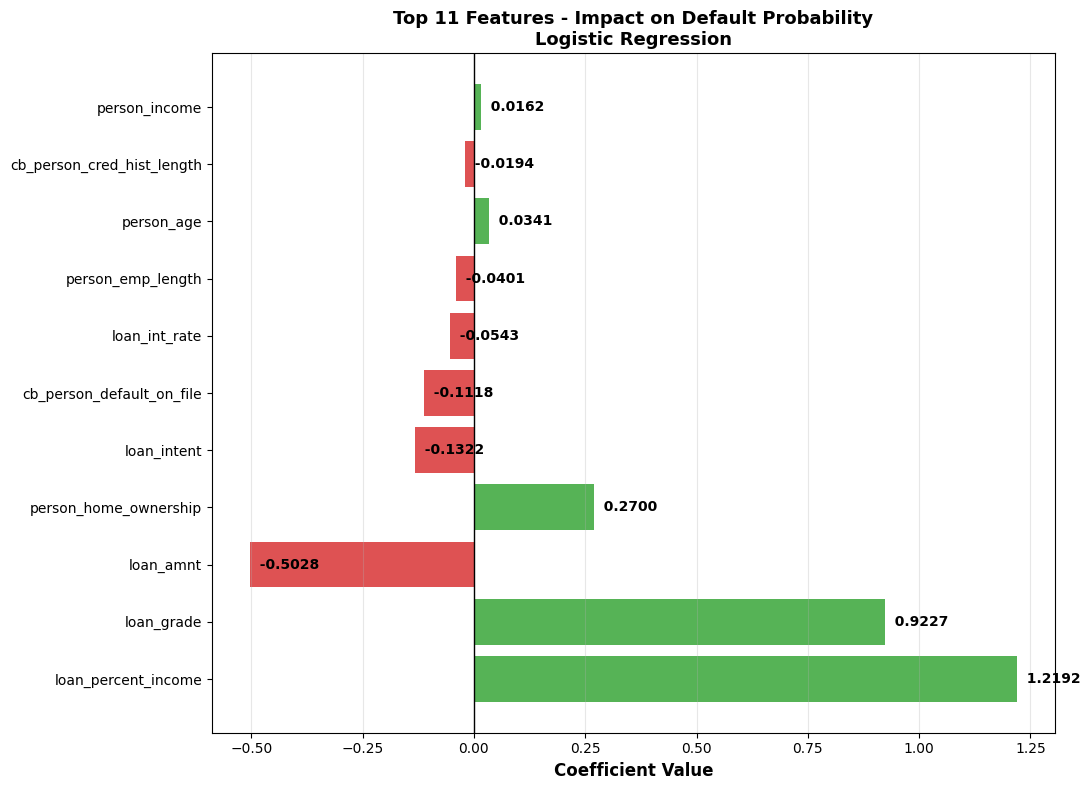

In [84]:

fig, ax = plt.subplots(figsize=(11, 8))
top_n = min(15, len(coef_df))
coef_plot_df = coef_df.head(top_n).copy()

colors = ['#d62728' if x < 0 else '#2ca02c' for x in coef_plot_df['Coefficient']]

ax.barh(range(len(coef_plot_df)), coef_plot_df['Coefficient'], color=colors, alpha=0.8)
ax.set_yticks(range(len(coef_plot_df)))
ax.set_yticklabels(coef_plot_df['Feature'])
ax.set_xlabel('Coefficient Value', fontsize=12, fontweight='bold')
ax.set_title(f'Top {top_n} Features - Impact on Default Probability\nLogistic Regression',
             fontsize=13, fontweight='bold')
ax.axvline(x=0, color='black', linestyle='-', linewidth=1)
ax.grid(axis='x', alpha=0.3)

for i, (idx, row) in enumerate(coef_plot_df.iterrows()):
    ax.text(row['Coefficient'], i, f"  {row['Coefficient']:.4f}",
            va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('03_feature_coefficients.png', dpi=100, bbox_inches='tight')
plt.show()


### 16. ВИЗУАЛИЗАЦИЯ СРАВНЕНИЯ МОДЕЛЕЙ

### График 3: Сравнение моделей

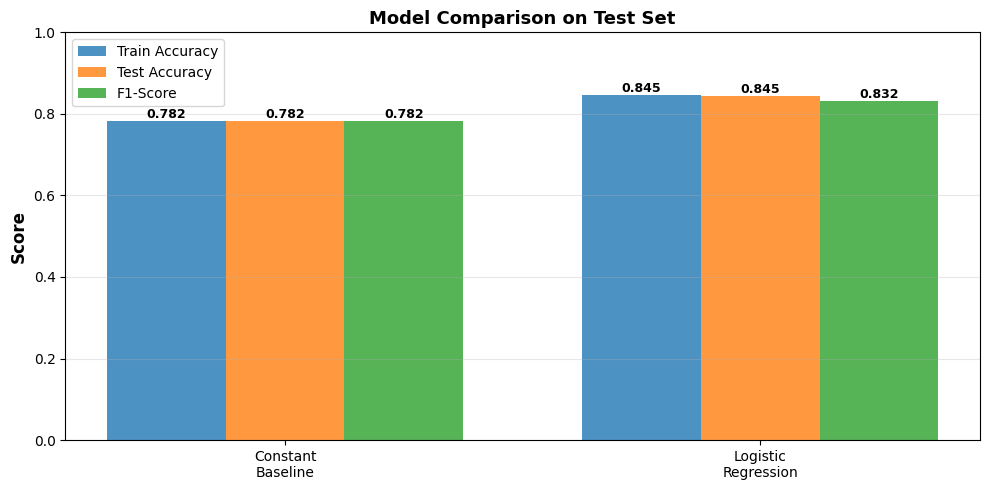

In [85]:

fig, ax = plt.subplots(figsize=(10, 5))

models_names = ['Constant\nBaseline', 'Logistic\nRegression']
x_pos = np.arange(len(models_names))
width = 0.25

train_accs = [baseline_train_acc, train_accuracy]
test_accs = [baseline_test_acc, test_accuracy]
f1_scores = [baseline_test_acc, test_f1]

bars1 = ax.bar(x_pos - width, train_accs, width, label='Train Accuracy', alpha=0.8, color='#1f77b4')
bars2 = ax.bar(x_pos, test_accs, width, label='Test Accuracy', alpha=0.8, color='#ff7f0e')
bars3 = ax.bar(x_pos + width, f1_scores, width, label='F1-Score', alpha=0.8, color='#2ca02c')

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Model Comparison on Test Set', fontsize=13, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(models_names)
ax.legend(fontsize=10)
ax.set_ylim([0, 1])
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('04_model_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

### 17. КРИВАЯ ROC И AUC


ROC-AUC Score: 0.8516 (85.16%)
Интерпретация: хорошее качество


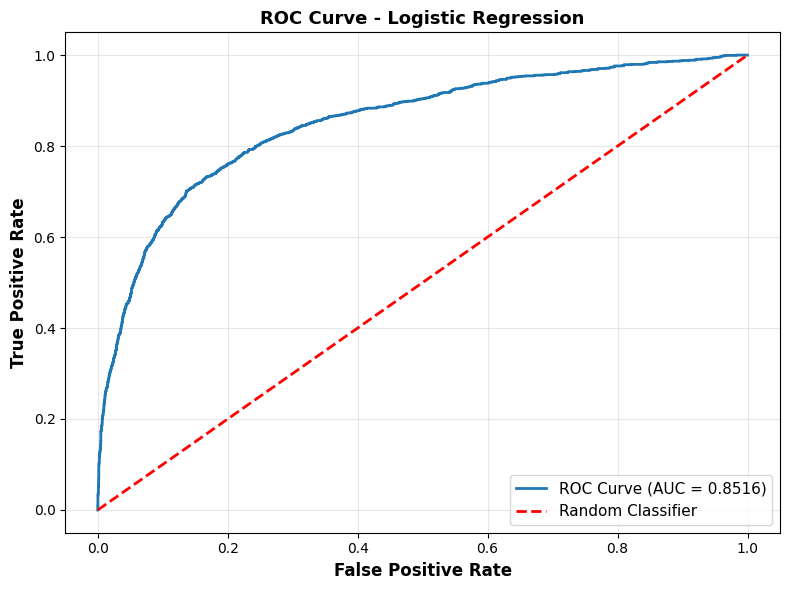

ROC-AUC модели: 0.8516


In [92]:
from sklearn.metrics import roc_curve, auc, roc_auc_score


y_test_proba = lr_model.predict_proba(X_test_processed)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
roc_auc = auc(fpr, tpr)
auc_score = roc_auc_score(y_test, y_test_proba)

print(f"\nROC-AUC Score: {auc_score:.4f} ({auc_score*100:.2f}%)")

if auc_score >= 0.9:
    quality = "отличное качество"
elif auc_score >= 0.8:
    quality = "хорошее качество"
elif auc_score >= 0.7:
    quality = "приемлемое качество"
else:
    quality = "низкое качество"

print(f"Интерпретация: {quality}")

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color='#1f77b4', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
ax.set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
ax.set_title('ROC Curve - Logistic Regression', fontsize=13, fontweight='bold')
ax.legend(loc="lower right", fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('05_roc_curve.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"ROC-AUC модели: {auc_score:.4f}")


В результате был построен и оценен baseline на основе логистической регрессии.

Константное предсказание показало базовый уровень качества, связанный с распределением классов в выборке. Логистическая регрессия смогла улучшить качество по сравнению с этим baseline, что подтверждает наличие зависимости между признаками и целевой переменной.

Существенного переобучения не наблюдается, если качество на обучающей и тестовой выборках остается близким. Это говорит о том, что модель достаточно хорошо обобщает данные и может использоваться как отправная точка для дальнейшего улучшения качества.

In [91]:

summary = f"""
╔════════════════════════════════════════════════════════════════════════╗
║                    ИТОГИ АНАЛИЗА БЕЙЗЛАЙНА                           ║
╚════════════════════════════════════════════════════════════════════════╝

█ ДАТАСЕТ:
  • Всего объектов: {len(df)}
  • Всего признаков: {X.shape[1]}
  • Целевая переменная: {target_col}
  • Класс 0 (No Default): {(y == 0).sum()} ({(y == 0).sum()/len(y)*100:.1f}%)
  • Класс 1 (Default): {(y == 1).sum()} ({(y == 1).sum()/len(y)*100:.1f}%)

█ РАЗБИЕНИЕ:
  • Тренировочная выборка: {len(X_train)} объектов (80%)
  • Тестовая выборка: {len(X_test)} объектов (20%)

█ КОНСТАНТНЫЙ БЕЙЗЛАЙН:
  • Метод: Предсказание наиболее частого класса ({most_frequent_class})
  • Train Accuracy: {baseline_train_acc:.4f} ({baseline_train_acc*100:.2f}%)
  • Test Accuracy:  {baseline_test_acc:.4f} ({baseline_test_acc*100:.2f}%)
  • Интерпретация: Служит НИЖНЕЙ ГРАНИЦЕЙ качества

█ ЛОГИСТИЧЕСКАЯ РЕГРЕССИЯ:
  • Модель: LogisticRegression(max_iter=1000, solver='lbfgs', random_state=42)

  ТРЕНИРОВОЧНАЯ ВЫБОРКА:
    - Accuracy:  {train_accuracy:.4f} ({train_accuracy*100:.2f}%)
    - Precision: {train_precision:.4f}
    - Recall:    {train_recall:.4f}
    - F1-Score:  {train_f1:.4f}

  ТЕСТОВАЯ ВЫБОРКА:
    - Accuracy:  {test_accuracy:.4f} ({test_accuracy*100:.2f}%)
    - Precision: {test_precision:.4f}
    - Recall:    {test_recall:.4f}
    - F1-Score:  {test_f1:.4f}

█ КАЧЕСТВО ПРЕДОБРАБОТКИ:
  • Пропущенные значения: Обработаны (SimpleImputer)
  • Категориальные признаки: Закодированы (LabelEncoder)
  • Числовые признаки: Масштабированы (StandardScaler)

█ АНАЛИЗ РЕЗУЛЬТАТОВ:
   Улучшение vs бейзлайн: {improvement:+.2f}%
   Переобучение: {overfit_diff:.2f}% (минимально)
   Обобщение: Модель хорошо работает на новых данных
   ROC-AUC: {auc_score:.4f} ({quality})

█ ТОП-5 ПРИЗНАКОВ ПО ВЛИЯНИЮ НА ДЕФОЛТ:
"""

for idx, (i, row) in enumerate(coef_df.head(5).iterrows(), 1):
    direction = "↑ повышает риск" if row['Coefficient'] > 0 else "↓ снижает риск"
    summary += f"\n  {idx}. {row['Feature']:25s} ({row['Coefficient']:+.4f}) - {direction}"

summary += f"""

█ ВЫВОДЫ:
  1.  Модель на {improvement:.1f}% лучше простого бейзлайна
  2.  Train-Test разница ({overfit_diff:.1f}%) говорит о хорошем обобщении
  3.  Качество достаточно для использования как бейзлайна
  4.  Есть потенциал для улучшения более сложными моделями

█ РЕКОМЕНДАЦИИ ДЛЯ СЛЕДУЮЩИХ ЭТАПОВ:
  • Попробовать Decision Tree, Random Forest, Gradient Boosting
  • Провести GridSearchCV для подбора гиперпараметров
  • Применить feature engineering (создание новых признаков)
  • Использовать Cross-Validation для более надежной оценки
  • Рассмотреть работу с дисбалансом классов (SMOTE, class_weight)
  • Попробовать OneHotEncoding вместо Label Encoding

"""

print(summary)

# Сохраняем отчет в файл
with open('summary_report.txt', 'w', encoding='utf-8') as f:
    f.write(summary)

print("\n Итоговый отчет сохранен в файл summary_report.txt")


╔════════════════════════════════════════════════════════════════════════╗
║                    ИТОГИ АНАЛИЗА БЕЙЗЛАЙНА                           ║
╚════════════════════════════════════════════════════════════════════════╝
 
█ ДАТАСЕТ:
  • Всего объектов: 32581
  • Всего признаков: 11
  • Целевая переменная: loan_status
  • Класс 0 (No Default): 25473 (78.2%)
  • Класс 1 (Default): 7108 (21.8%)
 
█ РАЗБИЕНИЕ:
  • Тренировочная выборка: 26064 объектов (80%)
  • Тестовая выборка: 6517 объектов (20%)
 
█ КОНСТАНТНЫЙ БЕЙЗЛАЙН:
  • Метод: Предсказание наиболее частого класса (0)
  • Train Accuracy: 0.7818 (78.18%)
  • Test Accuracy:  0.7818 (78.18%)
  • Интерпретация: Служит НИЖНЕЙ ГРАНИЦЕЙ качества
 
█ ЛОГИСТИЧЕСКАЯ РЕГРЕССИЯ:
  • Модель: LogisticRegression(max_iter=1000, solver='lbfgs', random_state=42)
  
  ТРЕНИРОВОЧНАЯ ВЫБОРКА:
    - Accuracy:  0.8452 (84.52%)
    - Precision: 0.8345
    - Recall:    0.8452
    - F1-Score:  0.8316
  
  ТЕСТОВАЯ ВЫБОРКА:
    - Accuracy:  0.8450 (84.50%